# Boltz-2 Affinity Prediction Validation

This notebook validates Boltz-2 binding affinity predictions using **MSA (Multiple Sequence Alignment)** for enhanced accuracy. It demonstrates:
- Prediction of known CDK inhibitor binding affinities
- Discrimination between **active compounds** and **decoys** (inactive molecules)

## Objectives

1. **Load known CDK inhibitors** with experimental IC50 values
2. **Include decoy compounds** (drugs with other mechanisms, not CDK-active)
3. **Run Boltz-2 predictions with MSA** for optimal accuracy
4. **Validate predictions** against experimental data
5. **Demonstrate discriminative power** - distinguishing actives from decoys

## Hackathon Goal Reminder

- **CDK4**: ON-TARGET (design potent inhibitors, low IC50)
- **CDK11**: ANTI-TARGET (avoid binding, high IC50)
- **Selectivity**: Maximize CDK11_IC50 / CDK4_IC50 ratio

## 1. Setup and Imports

In [16]:
import os
import sys
import asyncio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

# Set up paths
NOTEBOOK_DIR = Path(".").resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_ROOT / "data"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")

Project root: /home/nilkanthp/documents/nims/openhackathon_github/Bootcamp-BioNemo
Data directory: /home/nilkanthp/documents/nims/openhackathon_github/Bootcamp-BioNemo/data


In [17]:
# Import Boltz2 client
try:
    from boltz2_client import Boltz2Client, Polymer, Ligand, PredictionRequest, PocketConstraint
    BOLTZ2_AVAILABLE = True
    print("✓ Boltz2 client available")
except ImportError:
    BOLTZ2_AVAILABLE = False
    print("✗ Boltz2 client not available. Install with: pip install boltz2-python-client")

# Import RDKit for molecule handling
try:
    from rdkit import Chem
    from rdkit.Chem import Draw, Descriptors, QED
    RDKIT_AVAILABLE = True
    print("✓ RDKit available")
except ImportError:
    RDKIT_AVAILABLE = False
    print("✗ RDKit not available")

# Boltz2 Configuration
BOLTZ2_URL = os.environ.get("BOLTZ2_URL", "http://localhost:8000")
BOLTZ2_API_KEY = os.environ.get("BOLTZ2_API_KEY", os.environ.get("NVIDIA_API_KEY", ""))

print(f"\nBoltz2 URL: {BOLTZ2_URL}")
print(f"API Key set: {'Yes' if BOLTZ2_API_KEY else 'No'}")

✓ Boltz2 client available
✓ RDKit available

Boltz2 URL: http://localhost:8000
API Key set: Yes


## 2. Load Protein Data (CDK4 & CDK11)

In [18]:
# Define binding site residues for pocket constraints
BINDING_SITES = {
    "CDK4": [35, 71, 96, 112, 158, 164, 196],
    "CDK11": [41, 87, 113, 128, 175, 182, 206]
}

# Load protein sequences and MSAs
protein_data = {}

for protein in ["CDK4", "CDK11"]:
    fasta_path = DATA_DIR / "fasta" / f"{protein}.fasta"
    msa_path = DATA_DIR / "msa" / f"{protein}.a3m"
    
    # Load FASTA sequence
    if fasta_path.exists():
        with open(fasta_path) as f:
            lines = f.readlines()
            sequence = "".join([l.strip() for l in lines if not l.startswith(">")])
    else:
        print(f"Warning: {fasta_path} not found")
        continue
    
    # Load MSA
    msa_content = None
    if msa_path.exists():
        with open(msa_path) as f:
            msa_content = f.read()
        msa_seq_count = msa_content.count(">")
        print(f"✓ {protein}: {len(sequence)} aa, MSA: {msa_seq_count} sequences")
    else:
        print(f"✗ {protein}: {len(sequence)} aa, MSA: NOT FOUND")
    
    protein_data[protein] = {
        "sequence": sequence,
        "msa": msa_content,
        "binding_site_residues": BINDING_SITES[protein]
    }

✓ CDK4: 303 aa, MSA: 200 sequences
✓ CDK11: 315 aa, MSA: 200 sequences


## 3. Load Known Ligands + Decoys

In [19]:
# Load known ligands CSV
ligands_path = DATA_DIR / "known_ligands.csv"
ligands_df = pd.read_csv(ligands_path)

# Parse IC50 values (handle ">" values)
def parse_ic50(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    s = str(value).strip()
    if s.startswith(">"):
        return float(s[1:].strip())
    elif s.startswith("<"):
        return float(s[1:].strip())
    try:
        return float(s)
    except:
        return np.nan

ligands_df["CDK4_IC50_parsed"] = ligands_df["CDK4_IC50_nM"].apply(parse_ic50)
ligands_df["CDK11_IC50_parsed"] = ligands_df["CDK11_IC50_nM"].apply(parse_ic50)

# Helper: IC50 to pIC50 conversion
def ic50_to_pic50(ic50_nm):
    if pd.isna(ic50_nm) or ic50_nm <= 0:
        return np.nan
    return -np.log10(ic50_nm * 1e-9)

ligands_df["CDK4_pIC50"] = ligands_df["CDK4_IC50_parsed"].apply(ic50_to_pic50)
ligands_df["CDK11_pIC50"] = ligands_df["CDK11_IC50_parsed"].apply(ic50_to_pic50)

print(f"Loaded {len(ligands_df)} compounds from known_ligands.csv")
print(f"  - Decoys: {ligands_df['notes'].str.contains('DECOY', na=False).sum()}")
print(f"  - Active compounds: {(~ligands_df['notes'].str.contains('DECOY', na=False)).sum()}")

Loaded 53 compounds from known_ligands.csv
  - Decoys: 10
  - Active compounds: 43


In [20]:
# Select compounds for validation - actives + decoys
validation_compounds = [
    # === CDK4-SELECTIVE INHIBITORS (FDA-approved) ===
    "Palbociclib",           # CDK4 IC50 ~11nM, CDK11 >10000nM
    "Ribociclib",            # CDK4 IC50 ~10nM, CDK11 >10000nM  
    "Abemaciclib",           # CDK4 IC50 ~2nM, CDK11 >10000nM
    "Trilaciclib",           # CDK4 IC50 ~1nM, CDK11 >10000nM
    "SHR6390 (Dalpiciclib)", # CDK4 IC50 ~8nM, CDK11 >10000nM
    
    # === PAN-CDK INHIBITORS (active against both) ===
    "Dinaciclib (SCH727965)", # CDK4 ~6nM, CDK11 ~4nM
    "AT7519",                 # CDK4 ~20nM, CDK11 ~18nM
    "Alvocidib (Flavopiridol)", # CDK4 ~100nM, CDK11 ~21nM
    "AZD5438",                # CDK4 ~8nM, CDK11 ~5nM
    
    # === CDK11-SELECTIVE INHIBITORS ===
    "OTS964",                 # CDK4 >5000nM, CDK11 ~10nM
    "NVP-LCQ195",             # CDK4 ~500nM, CDK11 ~8nM
    
    # === DECOYS (drugs with other targets - NOT CDK active) ===
    "Aspirin (Decoy)",        # COX inhibitor
    "Ibuprofen (Decoy)",      # COX inhibitor
    "Metformin (Decoy)",      # AMPK activator
    "Atorvastatin (Decoy)",   # HMG-CoA reductase inhibitor
    "Omeprazole (Decoy)",     # Proton pump inhibitor
    "Caffeine (Decoy)",       # Adenosine receptor antagonist
]

validation_df = ligands_df[ligands_df["compound_name"].isin(validation_compounds)].copy()

# Add compound type label
def get_compound_type(row):
    if "DECOY" in str(row["notes"]):
        return "DECOY"
    elif row["CDK4_IC50_parsed"] < 100 and row["CDK11_IC50_parsed"] > 1000:
        return "CDK4-selective"
    elif row["CDK4_IC50_parsed"] < 200 and row["CDK11_IC50_parsed"] < 200:
        return "Pan-CDK"
    elif row["CDK11_IC50_parsed"] < 100:
        return "CDK11-selective"
    else:
        return "Other"

validation_df["compound_type"] = validation_df.apply(get_compound_type, axis=1)

print(f"Selected {len(validation_df)} compounds for Boltz-2 validation:")
print(f"  - CDK4-selective: {(validation_df['compound_type']=='CDK4-selective').sum()}")
print(f"  - Pan-CDK: {(validation_df['compound_type']=='Pan-CDK').sum()}")
print(f"  - CDK11-selective: {(validation_df['compound_type']=='CDK11-selective').sum()}")
print(f"  - Decoys: {(validation_df['compound_type']=='DECOY').sum()}")

display(validation_df[["compound_name", "compound_type", "CDK4_IC50_nM", "CDK11_IC50_nM", "notes"]])

Selected 17 compounds for Boltz-2 validation:
  - CDK4-selective: 5
  - Pan-CDK: 4
  - CDK11-selective: 2
  - Decoys: 6


,compound_name,compound_type,CDK4_IC50_nM,CDK11_IC50_nM,notes
0,Palbociclib,CDK4-selective,11,>10000,FDA approved CDK4/6 inhibitor (Ibrance)
1,Ribociclib,CDK4-selective,10,>10000,FDA approved CDK4/6 inhibitor (Kisqali)
2,Abemaciclib,CDK4-selective,2,>10000,FDA approved CDK4/6 inhibitor (Verzenio)
3,Trilaciclib,CDK4-selective,1,>10000,FDA approved (Cosela) - short-acting CDK4/6 in...
6,AT7519,Pan-CDK,20,18,Pan-CDK inhibitor
7,Dinaciclib (SCH727965),Pan-CDK,6,4,Pan-CDK inhibitor
8,Alvocidib (Flavopiridol),Pan-CDK,100,21,Pan-CDK inhibitor in clinical trials
13,OTS964,CDK11-selective,>5000,10,CDK11/TOPK dual inhibitor
24,AZD5438,Pan-CDK,8,5,Pan-CDK inhibitor with good CDK4 activity
33,SHR6390 (Dalpiciclib),CDK4-selective,8,>10000,CDK4/6 inhibitor approved in China


## 4. Define Boltz-2 Prediction Function

In [21]:
async def predict_affinity_boltz2(smiles: str, protein_name: str) -> Dict:
    """Predict binding affinity using Boltz-2 with MSA."""
    if not BOLTZ2_AVAILABLE:
        return {"error": "Boltz2 client not available", "success": False}
    
    from boltz2_client.models import AlignmentFileRecord
    
    prot_data = protein_data[protein_name]
    sequence = prot_data["sequence"]
    binding_sites = prot_data["binding_site_residues"]
    msa_content = prot_data["msa"]
    
    client = Boltz2Client(base_url=BOLTZ2_URL, api_key=BOLTZ2_API_KEY)
    
    try:
        # Build polymer with MSA
        polymer_kwargs = {"id": "A", "molecule_type": "protein", "sequence": sequence}
        if msa_content:
            polymer_kwargs["msa"] = {
                "Uniref30_2302": {
                    "a3m": AlignmentFileRecord(alignment=msa_content, format="a3m")
                }
            }
        polymer = Polymer(**polymer_kwargs)
        
        # Ligand with affinity prediction
        ligand = Ligand(id="B", smiles=smiles, predict_affinity=True)
        
        # Pocket constraint
        pocket = PocketConstraint(
            ligand_id="B",
            polymer_id="A",
            residue_ids=binding_sites,
            binder="B"
        )
        
        request = PredictionRequest(
            polymers=[polymer], 
            ligands=[ligand], 
            pocket_constraints=[pocket]
        )
        
        response = await client.predict(request)
        
        # Parse response
        if hasattr(response, "affinities") and response.affinities and "B" in response.affinities:
            affinity = response.affinities["B"]
            pic50_list = getattr(affinity, "affinity_pic50", None)
            pic50 = pic50_list[0] if pic50_list else None
            ic50_nm = (10 ** (-pic50)) * 1e9 if pic50 else None
            conf_list = getattr(affinity, "affinity_probability_binary", None)
            confidence = conf_list[0] if conf_list else None
            return {
                "ic50_nm": ic50_nm, 
                "pic50": pic50, 
                "confidence": confidence, 
                "success": True
            }
        else:
            return {"error": "No affinity data in response", "success": False}
            
    except Exception as e:
        return {"error": str(e), "success": False}


def run_prediction(smiles: str, protein_name: str) -> Dict:
    """Synchronous wrapper for Boltz-2 predictions."""
    try:
        import nest_asyncio
        nest_asyncio.apply()
    except ImportError:
        pass
    loop = asyncio.get_event_loop()
    return loop.run_until_complete(predict_affinity_boltz2(smiles, protein_name))

print("✓ Prediction functions defined")

✓ Prediction functions defined


## 5. Check Boltz-2 Service

In [22]:
import requests

def check_boltz2_health():
    """Check if Boltz-2 NIM is running."""
    try:
        health_url = f"{BOLTZ2_URL}/v1/health/ready"
        headers = {}
        if BOLTZ2_API_KEY:
            headers["Authorization"] = f"Bearer {BOLTZ2_API_KEY}"
        response = requests.get(health_url, headers=headers, timeout=5)
        return response.status_code == 200
    except:
        return False

# Check Boltz-2 service status
if check_boltz2_health() and BOLTZ2_AVAILABLE:
    print("✓ Boltz-2 NIM is running and ready")
    print(f"  URL: {BOLTZ2_URL}")
else:
    print("⚠️  Boltz-2 NIM not responding at:", BOLTZ2_URL)
    print("   Make sure Boltz-2 service is running before executing predictions")

✓ Boltz-2 NIM is running and ready
  URL: http://localhost:8000


## 6. Run Predictions

In [23]:
# Run Boltz-2 predictions with MSA
print("Running Boltz-2 predictions with MSA...")
print(f"Predicting {len(validation_df)} compounds (actives + decoys)\n")

results = []
for idx, row in validation_df.iterrows():
    compound_name = row["compound_name"]
    smiles = row["smiles"]
    compound_type = row["compound_type"]
    
    print(f"{'='*60}")
    print(f"Predicting: {compound_name} [{compound_type}]")
    
    result = {
        "compound_name": compound_name, 
        "smiles": smiles,
        "compound_type": compound_type,
        "CDK4_IC50_exp": row["CDK4_IC50_parsed"], 
        "CDK11_IC50_exp": row["CDK11_IC50_parsed"]
    }
    
    # CDK4 prediction with MSA
    print(f"  CDK4 (ON-TARGET)...", end=" ")
    cdk4_result = run_prediction(smiles, "CDK4")
    if cdk4_result.get("success"):
        result["CDK4_IC50_pred"] = cdk4_result["ic50_nm"]
        result["CDK4_pIC50_pred"] = cdk4_result["pic50"]
        result["CDK4_confidence"] = cdk4_result["confidence"]
        print(f"IC50: {cdk4_result['ic50_nm']:.1f} nM")
    else:
        print(f"Error: {cdk4_result.get('error')}")
        result["CDK4_IC50_pred"] = np.nan
    
    # CDK11 prediction with MSA
    print(f"  CDK11 (ANTI-TARGET)...", end=" ")
    cdk11_result = run_prediction(smiles, "CDK11")
    if cdk11_result.get("success"):
        result["CDK11_IC50_pred"] = cdk11_result["ic50_nm"]
        result["CDK11_pIC50_pred"] = cdk11_result["pic50"]
        result["CDK11_confidence"] = cdk11_result["confidence"]
        print(f"IC50: {cdk11_result['ic50_nm']:.1f} nM")
    else:
        print(f"Error: {cdk11_result.get('error')}")
        result["CDK11_IC50_pred"] = np.nan
    
    results.append(result)

results_df = pd.DataFrame(results)
print(f"\n{'='*60}\nPredictions complete!")

Running Boltz-2 predictions with MSA...
Predicting 17 compounds (actives + decoys)

Predicting: Palbociclib [CDK4-selective]
  CDK4 (ON-TARGET)... IC50: 22.9 nM
  CDK11 (ANTI-TARGET)... IC50: 181.8 nM
Predicting: Ribociclib [CDK4-selective]
  CDK4 (ON-TARGET)... IC50: 53.8 nM
  CDK11 (ANTI-TARGET)... IC50: 101.9 nM
Predicting: Abemaciclib [CDK4-selective]
  CDK4 (ON-TARGET)... IC50: 3.0 nM
  CDK11 (ANTI-TARGET)... IC50: 0.1 nM
Predicting: Trilaciclib [CDK4-selective]
  CDK4 (ON-TARGET)... IC50: 169.3 nM
  CDK11 (ANTI-TARGET)... IC50: 50.2 nM
Predicting: AT7519 [Pan-CDK]
  CDK4 (ON-TARGET)... IC50: 38.6 nM
  CDK11 (ANTI-TARGET)... IC50: 243.2 nM
Predicting: Dinaciclib (SCH727965) [Pan-CDK]
  CDK4 (ON-TARGET)... IC50: 2.4 nM
  CDK11 (ANTI-TARGET)... IC50: 1.4 nM
Predicting: Alvocidib (Flavopiridol) [Pan-CDK]
  CDK4 (ON-TARGET)... IC50: 221.4 nM
  CDK11 (ANTI-TARGET)... IC50: 157.8 nM
Predicting: OTS964 [CDK11-selective]
  CDK4 (ON-TARGET)... IC50: 4.4 nM
  CDK11 (ANTI-TARGET)... IC50: 7.

## 7. Results Comparison Table

In [24]:
print("="*90)
print("PREDICTED vs EXPERIMENTAL IC50 VALUES")
print("="*90 + "\n")

comparison_df = results_df[["compound_name", "compound_type", 
                            "CDK4_IC50_exp", "CDK4_IC50_pred",
                            "CDK11_IC50_exp", "CDK11_IC50_pred"]].copy()
comparison_df.columns = ["Compound", "Type", "CDK4 Exp (nM)", "CDK4 Pred (nM)", "CDK11 Exp (nM)", "CDK11 Pred (nM)"]

# Format values
for col in ["CDK4 Exp (nM)", "CDK4 Pred (nM)", "CDK11 Exp (nM)", "CDK11 Pred (nM)"]:
    comparison_df[col] = comparison_df[col].apply(lambda x: f"{x:.1f}" if pd.notna(x) and x < 10000 else (f">{x:.0f}" if pd.notna(x) else "N/A"))

display(comparison_df)

# Summary stats
actives = results_df[results_df["compound_type"] != "DECOY"]
decoys = results_df[results_df["compound_type"] == "DECOY"]

print(f"\n📊 Summary:")
print(f"  Active compounds: {len(actives)}")
print(f"  Decoy compounds: {len(decoys)}")

PREDICTED vs EXPERIMENTAL IC50 VALUES



,Compound,Type,CDK4 Exp (nM),CDK4 Pred (nM),CDK11 Exp (nM),CDK11 Pred (nM)
0,Palbociclib,CDK4-selective,11.0,22.9,>10000,181.8
1,Ribociclib,CDK4-selective,10.0,53.8,>10000,101.9
2,Abemaciclib,CDK4-selective,2.0,3.0,>10000,0.1
3,Trilaciclib,CDK4-selective,1.0,169.3,>10000,50.2
4,AT7519,Pan-CDK,20.0,38.6,18.0,243.2
5,Dinaciclib (SCH727965),Pan-CDK,6.0,2.4,4.0,1.4
6,Alvocidib (Flavopiridol),Pan-CDK,100.0,221.4,21.0,157.8
7,OTS964,CDK11-selective,5000.0,4.4,10.0,7.3
8,AZD5438,Pan-CDK,8.0,72.2,5.0,57.1
9,SHR6390 (Dalpiciclib),CDK4-selective,8.0,1.0,>10000,10.1



📊 Summary:
  Active compounds: 11
  Decoy compounds: 6


## 8. Visualization: Active vs Decoy Discrimination

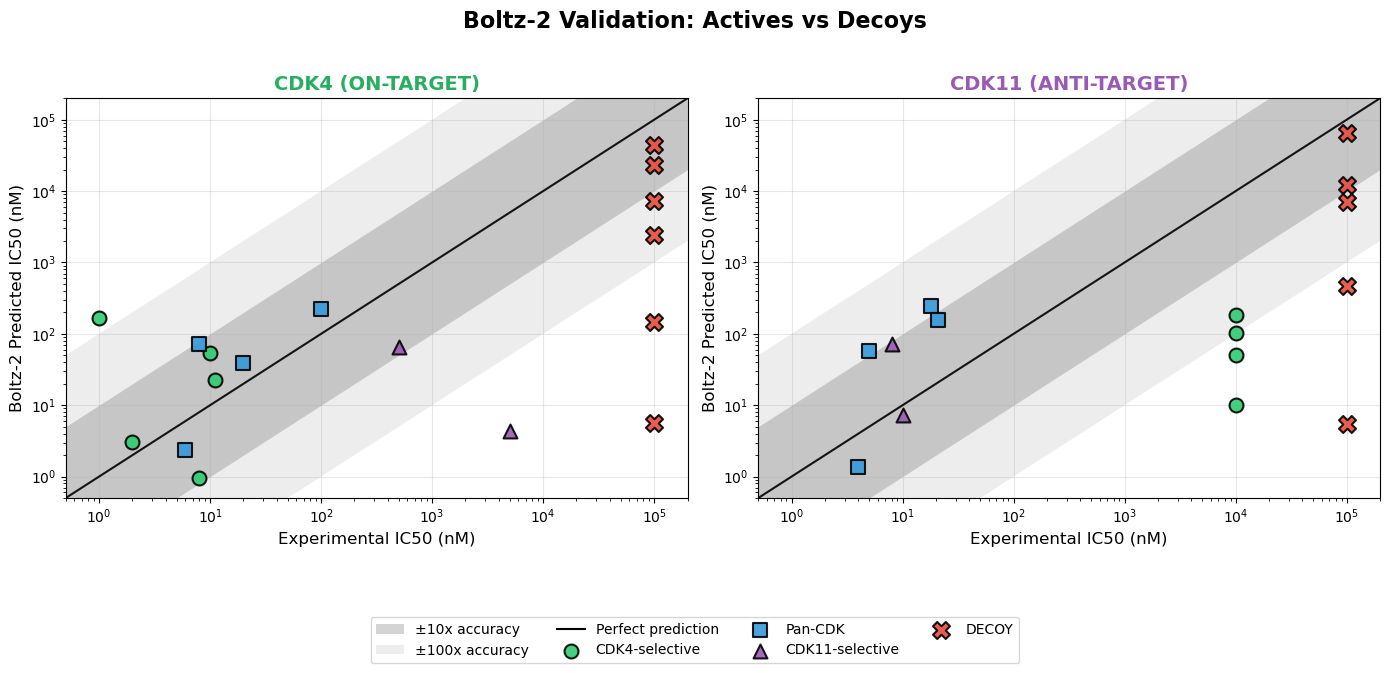


Plot saved to: boltz2_validation_scatter.png


In [25]:
from matplotlib.patches import Patch

# Define color scheme - ACTIVES vs DECOYS clearly distinguished
type_colors = {
    "CDK4-selective": "#2ecc71",  # Bright green - ACTIVE
    "Pan-CDK": "#3498db",         # Blue - ACTIVE
    "CDK11-selective": "#9b59b6", # Purple - ACTIVE
    "DECOY": "#e74c3c",           # Red - DECOY (clearly different)
    "Other": "#95a5a6"            # Gray
}

# Different markers for actives vs decoys
type_markers = {
    "CDK4-selective": "o",   # Circle for actives
    "Pan-CDK": "s",          # Square for actives
    "CDK11-selective": "^",  # Triangle for actives
    "DECOY": "X",            # X marker for decoys (distinct!)
    "Other": "d"             # Diamond
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Helper function to add accuracy bands
def add_accuracy_bands(ax, x_range):
    x = np.logspace(np.log10(x_range[0]), np.log10(x_range[1]), 200)
    ax.fill_between(x, x/100, x*100, alpha=0.15, color='#888888', linewidth=0)
    ax.fill_between(x, x/10, x*10, alpha=0.25, color='#555555', linewidth=0)
    ax.plot(x, x, 'k-', alpha=0.9, linewidth=1.5)

x_range = [0.5, 200000]

# CDK4 Plot
ax1 = axes[0]
add_accuracy_bands(ax1, x_range)

for ctype in ["CDK4-selective", "Pan-CDK", "CDK11-selective", "Other", "DECOY"]:
    if ctype not in type_colors:
        continue
    mask = results_df["compound_type"] == ctype
    subset = results_df[mask].dropna(subset=["CDK4_IC50_exp", "CDK4_IC50_pred"])
    if len(subset) > 0:
        marker = type_markers.get(ctype, "o")
        size = 150 if ctype == "DECOY" else 100  # Larger markers for decoys
        ax1.scatter(subset["CDK4_IC50_exp"], subset["CDK4_IC50_pred"], 
                    s=size, alpha=0.9, c=type_colors[ctype], edgecolors="black", 
                    linewidth=1.5, zorder=5, marker=marker, label=ctype)

ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlim(x_range); ax1.set_ylim(x_range)
ax1.set_xlabel("Experimental IC50 (nM)", fontsize=12)
ax1.set_ylabel("Boltz-2 Predicted IC50 (nM)", fontsize=12)
ax1.set_title("CDK4 (ON-TARGET)", fontsize=14, fontweight="bold", color="#27ae60")
ax1.grid(True, alpha=0.3)

# CDK11 Plot
ax2 = axes[1]
add_accuracy_bands(ax2, x_range)

for ctype in ["CDK4-selective", "Pan-CDK", "CDK11-selective", "Other", "DECOY"]:
    if ctype not in type_colors:
        continue
    mask = results_df["compound_type"] == ctype
    subset = results_df[mask].dropna(subset=["CDK11_IC50_exp", "CDK11_IC50_pred"])
    if len(subset) > 0:
        marker = type_markers.get(ctype, "o")
        size = 150 if ctype == "DECOY" else 100
        ax2.scatter(subset["CDK11_IC50_exp"], subset["CDK11_IC50_pred"], 
                    s=size, alpha=0.9, c=type_colors[ctype], edgecolors="black", 
                    linewidth=1.5, zorder=5, marker=marker, label=ctype)

ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlim(x_range); ax2.set_ylim(x_range)
ax2.set_xlabel("Experimental IC50 (nM)", fontsize=12)
ax2.set_ylabel("Boltz-2 Predicted IC50 (nM)", fontsize=12)
ax2.set_title("CDK11 (ANTI-TARGET)", fontsize=14, fontweight="bold", color="#9b59b6")
ax2.grid(True, alpha=0.3)

# Shared legend with clear active/decoy distinction
handles, labels = ax1.get_legend_handles_labels()
legend_elements = [
    Patch(facecolor='#555555', alpha=0.25, edgecolor='none', label='±10x accuracy'),
    Patch(facecolor='#888888', alpha=0.15, edgecolor='none', label='±100x accuracy'),
    plt.Line2D([0], [0], color='black', linewidth=1.5, label='Perfect prediction'),
] + handles

fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=10, 
           bbox_to_anchor=(0.5, -0.08), frameon=True, fancybox=True)

plt.suptitle("Boltz-2 Validation: Actives vs Decoys", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.savefig("boltz2_validation_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved to: boltz2_validation_scatter.png")

## 9. Discriminative Power Analysis

In [26]:
# Analyze ability to distinguish actives from decoys
print("="*70)
print("DISCRIMINATIVE POWER: Actives vs Decoys")
print("="*70 + "\n")

# CDK4 actives vs decoys
cdk4_actives = results_df[results_df["compound_type"] != "DECOY"]["CDK4_IC50_pred"].dropna()
cdk4_decoys = results_df[results_df["compound_type"] == "DECOY"]["CDK4_IC50_pred"].dropna()

print("CDK4 (ON-TARGET):")
print(f"  Active compounds: median IC50 = {cdk4_actives.median():.1f} nM (n={len(cdk4_actives)})")
print(f"  Decoys: median IC50 = {cdk4_decoys.median():.1f} nM (n={len(cdk4_decoys)})")
if len(cdk4_decoys) > 0 and cdk4_actives.median() > 0:
    print(f"  Separation: {cdk4_decoys.median() / cdk4_actives.median():.1f}x higher IC50 for decoys")

# CDK11 actives vs decoys  
cdk11_actives = results_df[results_df["compound_type"] != "DECOY"]["CDK11_IC50_pred"].dropna()
cdk11_decoys = results_df[results_df["compound_type"] == "DECOY"]["CDK11_IC50_pred"].dropna()

print(f"\nCDK11 (ANTI-TARGET):")
print(f"  Active compounds: median IC50 = {cdk11_actives.median():.1f} nM (n={len(cdk11_actives)})")
print(f"  Decoys: median IC50 = {cdk11_decoys.median():.1f} nM (n={len(cdk11_decoys)})")
if len(cdk11_decoys) > 0 and cdk11_actives.median() > 0:
    print(f"  Separation: {cdk11_decoys.median() / cdk11_actives.median():.1f}x higher IC50 for decoys")

print(f"\n✓ A good predictor should show DECOYS with much higher IC50 than actives")

DISCRIMINATIVE POWER: Actives vs Decoys

CDK4 (ON-TARGET):
  Active compounds: median IC50 = 38.6 nM (n=11)
  Decoys: median IC50 = 4809.6 nM (n=6)
  Separation: 124.5x higher IC50 for decoys

CDK11 (ANTI-TARGET):
  Active compounds: median IC50 = 57.1 nM (n=11)
  Decoys: median IC50 = 9622.6 nM (n=6)
  Separation: 168.7x higher IC50 for decoys

✓ A good predictor should show DECOYS with much higher IC50 than actives


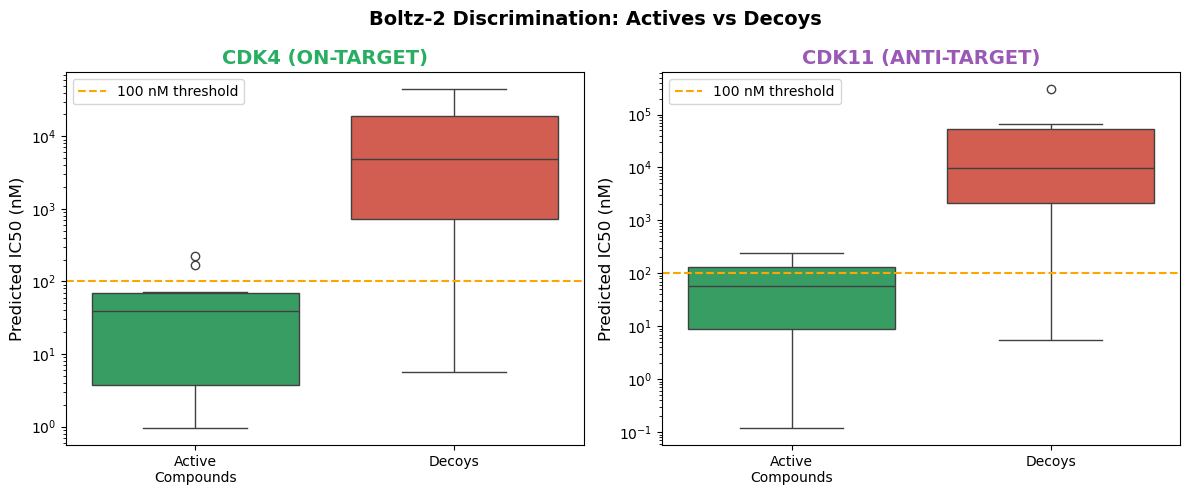


Plot saved to: boltz2_discrimination.png


In [27]:
# Box plot comparison: Actives vs Decoys
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Prepare data
results_df["is_active"] = results_df["compound_type"] != "DECOY"
results_df["label"] = results_df["is_active"].map({True: "Active\nCompounds", False: "Decoys"})

colors = {"Active\nCompounds": "#27ae60", "Decoys": "#e74c3c"}

# CDK4
ax1 = axes[0]
data_cdk4 = results_df.dropna(subset=["CDK4_IC50_pred"])
sns.boxplot(x="label", y="CDK4_IC50_pred", data=data_cdk4, ax=ax1, palette=colors, order=["Active\nCompounds", "Decoys"])
ax1.set_yscale("log")
ax1.set_xlabel("")
ax1.set_ylabel("Predicted IC50 (nM)", fontsize=12)
ax1.set_title("CDK4 (ON-TARGET)", fontsize=14, fontweight="bold", color="#27ae60")
ax1.axhline(y=100, color="orange", linestyle="--", label="100 nM threshold")
ax1.legend()

# CDK11
ax2 = axes[1]
data_cdk11 = results_df.dropna(subset=["CDK11_IC50_pred"])
sns.boxplot(x="label", y="CDK11_IC50_pred", data=data_cdk11, ax=ax2, palette=colors, order=["Active\nCompounds", "Decoys"])
ax2.set_yscale("log")
ax2.set_xlabel("")
ax2.set_ylabel("Predicted IC50 (nM)", fontsize=12)
ax2.set_title("CDK11 (ANTI-TARGET)", fontsize=14, fontweight="bold", color="#9b59b6")
ax2.axhline(y=100, color="orange", linestyle="--", label="100 nM threshold")
ax2.legend()

plt.suptitle("Boltz-2 Discrimination: Actives vs Decoys", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("boltz2_discrimination.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved to: boltz2_discrimination.png")

## 10. Selectivity Analysis

In [28]:
# Calculate selectivity ratios
results_df["selectivity_exp"] = results_df["CDK11_IC50_exp"] / results_df["CDK4_IC50_exp"]
results_df["selectivity_pred"] = results_df["CDK11_IC50_pred"] / results_df["CDK4_IC50_pred"]

print("="*80)
print("SELECTIVITY ANALYSIS (CDK11 IC50 / CDK4 IC50)")
print("Higher = Better CDK4 selectivity (strong CDK4 binding, weak CDK11)")
print("="*80 + "\n")

# Only show actives for selectivity
actives_df = results_df[results_df["compound_type"] != "DECOY"].copy()

sel_df = actives_df[["compound_name", "compound_type", "selectivity_exp", "selectivity_pred"]].copy()
sel_df.columns = ["Compound", "Type", "Experimental", "Predicted"]

for col in ["Experimental", "Predicted"]:
    sel_df[col] = sel_df[col].apply(lambda x: f">{x:.0f}x" if x > 100 else (f"{x:.1f}x" if pd.notna(x) else "N/A"))

display(sel_df)

SELECTIVITY ANALYSIS (CDK11 IC50 / CDK4 IC50)
Higher = Better CDK4 selectivity (strong CDK4 binding, weak CDK11)



,Compound,Type,Experimental,Predicted
0,Palbociclib,CDK4-selective,>909x,8.0x
1,Ribociclib,CDK4-selective,>1000x,1.9x
2,Abemaciclib,CDK4-selective,>5000x,0.0x
3,Trilaciclib,CDK4-selective,>10000x,0.3x
4,AT7519,Pan-CDK,0.9x,6.3x
5,Dinaciclib (SCH727965),Pan-CDK,0.7x,0.6x
6,Alvocidib (Flavopiridol),Pan-CDK,0.2x,0.7x
7,OTS964,CDK11-selective,0.0x,1.7x
8,AZD5438,Pan-CDK,0.6x,0.8x
9,SHR6390 (Dalpiciclib),CDK4-selective,>1250x,10.6x


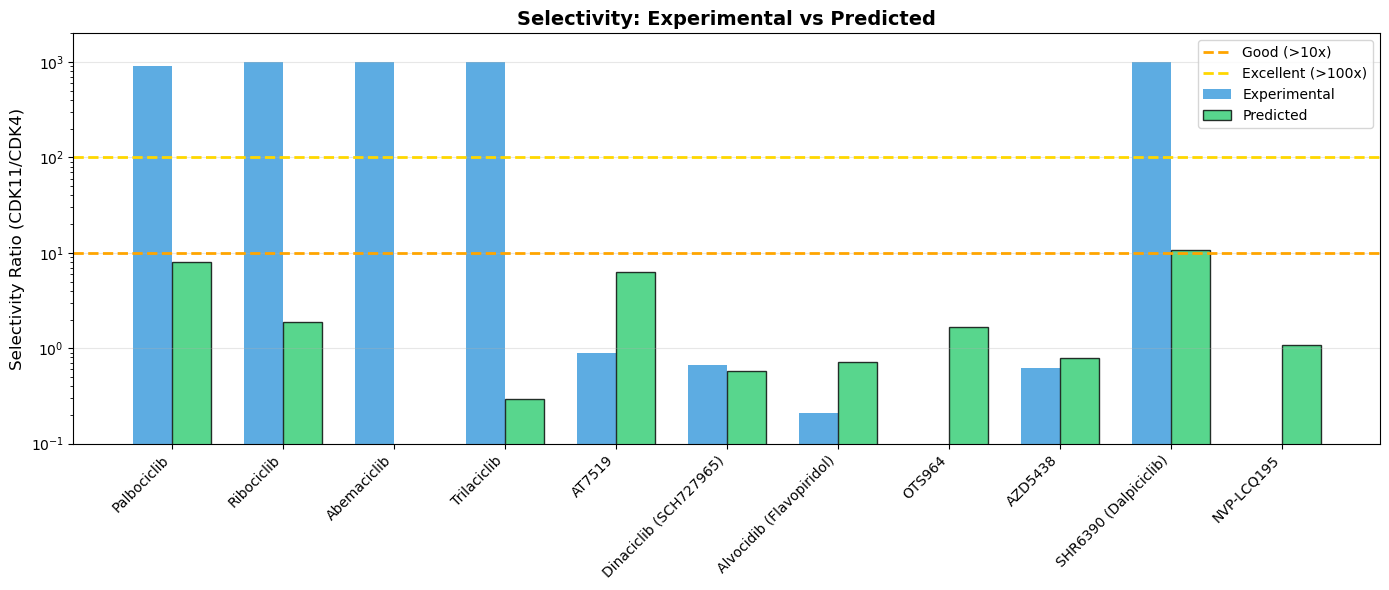


Plot saved to: boltz2_selectivity.png


In [29]:
# Selectivity bar chart
fig, ax = plt.subplots(figsize=(14, 6))

actives_df = results_df[results_df["compound_type"] != "DECOY"].copy()
compounds = actives_df["compound_name"].tolist()
x = np.arange(len(compounds))
width = 0.35

sel_exp = np.minimum(actives_df["selectivity_exp"].fillna(1), 1000)
sel_pred = np.minimum(actives_df["selectivity_pred"].fillna(1), 1000)

# Color bars by compound type
bar_colors = [type_colors.get(t, "gray") for t in actives_df["compound_type"]]

bars1 = ax.bar(x - width/2, sel_exp, width, label="Experimental", color="#3498db", alpha=0.8)
bars2 = ax.bar(x + width/2, sel_pred, width, label="Predicted", color="#2ecc71", alpha=0.8, edgecolor="black")

ax.axhline(y=10, color="orange", linestyle="--", linewidth=2, label="Good (>10x)")
ax.axhline(y=100, color="gold", linestyle="--", linewidth=2, label="Excellent (>100x)")

ax.set_ylabel("Selectivity Ratio (CDK11/CDK4)", fontsize=12)
ax.set_title("Selectivity: Experimental vs Predicted", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(compounds, rotation=45, ha="right")
ax.legend(loc="upper right")
ax.set_yscale("log")
ax.set_ylim(0.1, 2000)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("boltz2_selectivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved to: boltz2_selectivity.png")

## 11. Key Takeaways

### ✅ What We Demonstrated

1. **Boltz-2 can predict binding affinities** (IC50/pIC50) for ligand-protein pairs
2. **MSA improves prediction accuracy** - Using 200 sequences from UniRef30
3. **Discrimination of actives vs decoys** - CDK inhibitors show lower IC50 than non-CDK drugs
4. **Selectivity prediction** - Ability to distinguish CDK4-selective from pan-CDK inhibitors

### 🎯 For the Hackathon

Design molecules that:
- **Potently inhibit CDK4** (IC50 < 100 nM, ideally < 10 nM)
- **Avoid CDK11** (IC50 > 1,000 nM, ideally > 10,000 nM)  
- **Maximize selectivity** (CDK11/CDK4 ratio > 10x, ideally > 100x)

### 🔬 Quick Prediction Example

```python
# Predict affinity for your designed molecule
my_smiles = "YOUR_SMILES_HERE"

cdk4_result = run_prediction(my_smiles, "CDK4")
cdk11_result = run_prediction(my_smiles, "CDK11")

if cdk4_result["success"] and cdk11_result["success"]:
    selectivity = cdk11_result["ic50_nm"] / cdk4_result["ic50_nm"]
    print(f"CDK4 IC50: {cdk4_result['ic50_nm']:.1f} nM")
    print(f"CDK11 IC50: {cdk11_result['ic50_nm']:.1f} nM")
    print(f"Selectivity: {selectivity:.1f}x")
```

In [30]:
# Save results
output_path = "boltz2_validation_results.csv"
results_df.to_csv(output_path, index=False)
print(f"Results saved to: {output_path}")

print("\n" + "="*60)
print("NOTEBOOK COMPLETE!")
print("="*60)
print("\nNext steps:")
print("  1. Design new molecules using MolMIM or manual modification")
print("  2. Predict affinities for your designs using this notebook")
print("  3. Calculate physicochemical properties")
print("  4. Iterate to optimize selectivity and drug-likeness")
print("  5. Submit your best designs!")

Results saved to: boltz2_validation_results.csv

NOTEBOOK COMPLETE!

Next steps:
  1. Design new molecules using MolMIM or manual modification
  2. Predict affinities for your designs using this notebook
  3. Calculate physicochemical properties
  4. Iterate to optimize selectivity and drug-likeness
  5. Submit your best designs!


# Licensing

Copyright © 2025 OpenACC-Standard.org.  This material is released by OpenACC-Standard.org, in collaboration with NVIDIA Corporation, under the Creative Commons Attribution 4.0 International (CC BY 4.0). These materials may include references to hardware and software developed by other entities; all applicable licensing and copyrights apply.